# HOUSEHOLD VULNERABILITY ANALYTICS
**Identifikasi Rumah Tangga Rentan dan Analisis *Social Protection Gap***

**Konteks Kebijakan:**
Pengukuran kesejahteraan rumah tangga umumnya hanya berpusat pada dimensi moneter (Pengeluaran Per Kapita). Namun, dua rumah tangga dengan tingkat pengeluaran yang sama dapat memiliki tingkat kekurangan yang berbeda pada pemenuhan gizi dan standar perumahan dasar. 

**Tujuan Analisis:**
1. Mengembangkan *Vulnerability Index* multidimensi (Ekonomi, Pangan, Perumahan).
2. Memetakan *Social Protection Gap* untuk mengidentifikasi kelompok *Residual Vulnerability* (menerima bantuan namun tetap rentan) dan *Underserved* (rentan namun tidak menerima bantuan).
3. Membangun model Machine Learning untuk memprediksi profil rumah tangga berisiko tinggi.

**Sumber Data:**
SUSENAS September 2025 (Modul Kesehatan & Perumahan, Konsumsi Pengeluaran, dan Modul Individu untuk Kepala Rumah Tangga).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")

# STEP 1: LOAD DATASET
# Dataset ini merupakan hasil ETL (penggabungan) dari kp_blok43, mod_rt, dan mod_ind
print("Memuat dataset analitik...")
df = pd.read_csv('susenas_vulnerability_dataset.csv')

print(f"Total Observasi: {df.shape[0]:,} Rumah Tangga")
print(f"Total Fitur    : {df.shape[1]} Kolom")

Memuat dataset analitik...
Total Observasi: 76,928 Rumah Tangga
Total Fitur    : 19 Kolom


## STEP 2: MULTIDIMENSIONAL FEATURE ENGINEERING
Pendekatan *Rule-Based* digunakan untuk mendefinisikan tiga dimensi kerentanan:

1. **Economic Deprivation (`econ_vuln`)**: Rumah tangga berada pada 40% terbawah dari distribusi pengeluaran per kapita nasional.
2. **Food Deprivation (`food_vuln`)**: Konsumsi gizi di bawah standar minimum (Kalori < 2100 kkal atau Protein < 52 gram per kapita).
3. **Housing Deprivation (`housing_vuln`)**: Akses utilitas dasar yang buruk (contoh: penerangan utama bukan dari listrik PLN).

Rumah tangga diklasifikasikan memiliki **High Vulnerability** jika mengalami deprivasi pada minimal 2 dari 3 dimensi tersebut.

In [3]:
# A. Economic Deprivation (Bottom 40%)
threshold_40 = df['KAPITA'].quantile(0.40)
df['econ_vuln'] = (df['KAPITA'] <= threshold_40).astype(int)

# B. Food Deprivation (Kalori < 2100 atau Protein < 52)
df['food_vuln'] = ((df['CAL'] < 2100) | (df['PROT'] < 52)).astype(int)

# C. Housing Deprivation (M1504 kode 3: Listrik Non-PLN, 4: Bukan Listrik)
df['housing_vuln'] = df['M1504'].isin([3, 4]).astype(int)

# D. Aggregation: Vulnerability Score & Class
df['vulnerability_score'] = df['econ_vuln'] + df['food_vuln'] + df['housing_vuln']
df['high_vulnerability'] = (df['vulnerability_score'] >= 2).astype(int)

# Menyimpan data yang sudah ditambahkan target variabel untuk tahap ML
df.to_csv('susenas_ml_ready.csv', index=False)

## STEP 3: SOCIAL PROTECTION GAP MATRIX
Evaluasi *coverage* program perlindungan sosial (Bansos) terhadap status kerentanan rumah tangga. Matriks ini menggunakan nilai *weighting* (`FWT`) dari BPS agar persentase yang dihasilkan merepresentasikan estimasi populasi nasional yang sesungguhnya.

Fokus utama kita adalah mengidentifikasi dua kuadran:
*   **Potentially Underserved**: Rumah tangga rentan yang luput dari program bantuan.
*   **Residual Vulnerability**: Rumah tangga yang sudah diintervensi bantuan, namun masih terperangkap dalam kondisi rentan (indikasi ketidakcukupan nilai bantuan atau ketidaktepatan desain program).

In [4]:
# Kalkulasi Estimasi Populasi Nasional
total_pop = df['FWT'].sum()
high_vuln_pop = df[df['high_vulnerability'] == 1]['FWT'].sum()
bansos_pop = df[df['penerima_bansos'] == 1]['FWT'].sum()

print("=========================================================")
print("     HOUSEHOLD VULNERABILITY MONITOR (POPULATION ESTIMATE) ")
print("=========================================================")
print(f"Estimasi Populasi RT : {total_pop:,.0f} Rumah Tangga")
print(f"High Vulnerability   : {(high_vuln_pop / total_pop) * 100:.2f}%")
print(f"Penerima Bansos      : {(bansos_pop / total_pop) * 100:.2f}%\n")

# Membuat Crosstab Matrix berbobot
matrix = pd.crosstab(
    df['penerima_bansos'].map({0: 'No Assistance', 1: 'Assisted'}),
    df['high_vulnerability'].map({0: 'Low Vulnerability', 1: 'High Vulnerability'}),
    values=df['FWT'],
    aggfunc='sum',
    normalize='all'
) * 100

print("--- SOCIAL PROTECTION GAP MATRIX (%) ---")
display(matrix.round(2))

     HOUSEHOLD VULNERABILITY MONITOR (POPULATION ESTIMATE) 
Estimasi Populasi RT : 74,406,663 Rumah Tangga
High Vulnerability   : 32.56%
Penerima Bansos      : 35.40%

--- SOCIAL PROTECTION GAP MATRIX (%) ---


high_vulnerability,High Vulnerability,Low Vulnerability
penerima_bansos,,
Assisted,15.07,20.32
No Assistance,17.49,47.11


## STEP 4: DATA PREPARATION FOR MACHINE LEARNING
menggunakan algoritma klasifikasi untuk memprediksi status kerentanan rumah tangga. Sebelum masuk ke pemodelan, dataset perlu disiapkan (handling missing values, mengubah tipe data kategorikal menjadi *dummy variables*, dan pembagian dataset).

**Variabel Prediktor (Features):**
*   `krt_jk`: Jenis Kelamin Kepala Rumah Tangga (KRT)
*   `krt_umur`: Umur KRT
*   `krt_pendidikan`: Pendidikan Tertinggi KRT
*   `krt_bekerja`: Status Bekerja KRT
*   `M1501`: Status Kepemilikan Bangunan
*   `penerima_bansos`: Status menerima bantuan (sebagai prediktor untuk melihat dampaknya)

**Variabel Target:**
*   `high_vulnerability` (1 = Ya, 0 = Tidak)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# 1. Seleksi Fitur (Menambahkan M101 - Provinsi)
features = ['M101', 'krt_jk', 'krt_umur', 'krt_pendidikan', 'krt_bekerja', 'M1501', 'penerima_bansos']
target = 'high_vulnerability'

df_ml = df[features + [target]].dropna().copy()

# Konversi krt_bekerja
df_ml['krt_bekerja'] = df_ml['krt_bekerja'].apply(lambda x: 1 if str(x).strip() == 'A' else 0)

# 2. Encoding Variabel Kategorikal (Termasuk M101)
df_ml = pd.get_dummies(df_ml, columns=['M101', 'M1501', 'krt_pendidikan'], drop_first=True)

# 3. Definisi X dan y
X = df_ml.drop(columns=[target])
y = df_ml[target]

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah data latih (Train) : {X_train.shape[0]:,} baris")
print(f"Jumlah data uji (Test)    : {X_test.shape[0]:,} baris")

Jumlah data latih (Train) : 51,239 baris
Jumlah data uji (Test)    : 12,810 baris


## STEP 5: MODEL TRAINING & EVALUATION (RANDOM FOREST)
menggunakan **Random Forest** karena kemampuannya menangani interaksi non-linear antar variabel (contoh: hubungan antara umur, pendidikan, dan kerentanan) dan kemampuannya menghasilkan indikator *Feature Importance* yang sangat berguna untuk merumuskan kebijakan.

Model akan dievaluasi menggunakan metrik standar klasifikasi (Precision, Recall, F1-Score, dan ROC-AUC).

In [6]:
# 1. Pelatihan Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1)
print("Sedang melatih model Random Forest...")
rf_model.fit(X_train, y_train)

# 2. Pelatihan Model Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
print("Sedang melatih model Logistic Regression...")
lr_model.fit(X_train, y_train)
print("Pelatihan selesai!\n")

# 3. Evaluasi
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("=== EVALUASI ROC-AUC ===")
print(f"Random Forest       : {roc_auc_score(y_test, y_prob_rf):.3f}")
print(f"Logistic Regression : {roc_auc_score(y_test, y_prob_lr):.3f}")

Sedang melatih model Random Forest...
Sedang melatih model Logistic Regression...
Pelatihan selesai!

=== EVALUASI ROC-AUC ===
Random Forest       : 0.677
Logistic Regression : 0.680


## STEP 6: EXPLAINABILITY (FEATURE IMPORTANCE)
Model prediktif tidak boleh menjadi *black-box* (kotak hitam). Perlu mengekstrak bobot kepentingan variabel (*Feature Importance*) untuk memahami faktor demografis atau sosial-ekonomi mana yang paling kuat mendorong sebuah rumah tangga jatuh ke dalam status rentan.

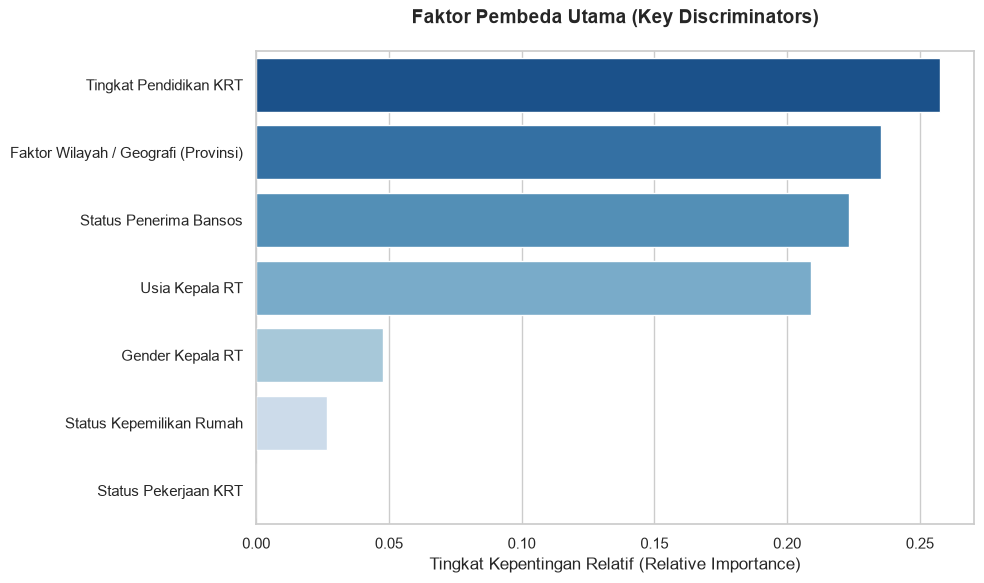

In [9]:
# Ekstrak feature importance mentah
raw_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Fungsi agregasi ke variabel induk
def map_to_group(feat):
    if feat.startswith('M101_'):
        return 'Faktor Wilayah / Geografi (Provinsi)'
    elif feat.startswith('krt_pendidikan_'):
        return 'Tingkat Pendidikan KRT'
    elif feat.startswith('M1501_'):
        return 'Status Kepemilikan Rumah'
    elif feat == 'penerima_bansos':
        return 'Status Penerima Bansos'
    elif feat == 'krt_umur':
        return 'Usia Kepala RT'
    elif feat == 'krt_jk':
        return 'Gender Kepala RT'
    elif feat == 'krt_bekerja':
        return 'Status Pekerjaan KRT'
    return feat

raw_importances['Group'] = raw_importances['Feature'].apply(map_to_group)
grouped_importances = raw_importances.groupby('Group')['Importance'].sum().reset_index()
grouped_importances = grouped_importances.sort_values(by='Importance', ascending=False)

# Visualisasi Grouped Features
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_importances, x='Importance', y='Group', palette='Blues_r')
plt.title('Faktor Pembeda Utama (Key Discriminators)', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan Relatif (Relative Importance)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## STEP 7: DEPLOYMENT DASHBOARD (STREAMLIT)
Catatan: Pembuatan skrip *dashboard* tidak lagi dieksekusi langsung dari *notebook* ini agar tidak menimpa file kode final yang sudah dibuat. 

Untuk melihat kode lengkap *dashboard* interaktifnya, silakan langsung cek file **`app.py`** dan **`save_artifacts.py`** di dalam repositori ini.

In [10]:
print("Proses analisis dan pemodelan selesai!")
print("=========================================================")
print("Langkah selanjutnya untuk Deployment Lokal:")
print("1. Jalankan skrip 'save_artifacts.py' untuk membuat file .joblib")
print("2. Buka terminal dan jalankan: streamlit run app.py")
print("=========================================================")

Proses analisis dan pemodelan selesai!
Langkah selanjutnya untuk Deployment Lokal:
1. Jalankan skrip 'save_artifacts.py' untuk membuat file .joblib
2. Buka terminal dan jalankan: streamlit run app.py
